# <b><font color='saddlebrown'>Проверка гипотез</font></b>

In [14]:
# Импорт библиотек
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### <b><font color='saddlebrown'>1. t-тесты</font></b>

##### <b><font color='saddlebrown'>1.1. Одновыборочный t-тест</font></b>
stats.ttest_1samp(a, popmean)

Сеть кофеен “EuroCafé” утверждает, что среднее содержание кофеина в одной чашке эспрессо — <b>90 мг</b>.
Бариста в одном из филиалов сомневается: ему кажется, что кофе слишком слабый, и кофеина там меньше.

Он берёт <b>случайную выборку из 12 чашек</b> и измеряет содержание кофеина (в мг):
82,88,91,85,84,86,83,89,90,87,85,84

<b>Проверить</b>, есть ли статистические основания утверждать, что среднее содержание кофеина в филиале меньше заявленных 90 мг (на уровне значимости α = 0.05).

In [15]:
# Запишите в список coffee_list значения из выборки с 12 чашками
coffee_list = [82, 88, 91, 85, 84, 86, 83, 89, 90, 87, 85, 84]

In [16]:
# В переменные t_statistic, p_value запишите результат работы функции ttest_1samp
# Функция ttest_1samp принимает следующие параметры:
# a - массив выборки
# popmean - ожидаемое значение (из гипотезы H0)
t_statistic, p_value = stats.ttest_1samp(a = coffee_list, popmean = 90)

In [17]:
# Выведите t_statistic, p_value на экран и сделайте вывод по задаче
# Если p-value < 0.05, то отвергаем H₀, значит, кофе действительно слабее.
# Если p-value ≥ 0.05, то нет оснований утверждать, что кофе отличается от стандарта.
print(f"T-статистика: {t_statistic}")
print(f"P-value: {p_value}")

T-статистика: -4.651018196075242
P-value: 0.0007039160988024213


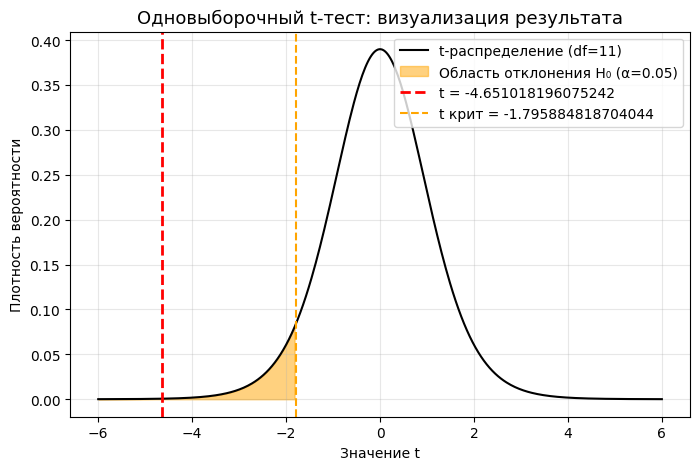

In [18]:
# Параметры
# Распределение t
x = np.linspace(-6, 6, 400)
y = stats.t.pdf(x, len(coffee_list) - 1)

# percent point function - Какое значение t даёт накопленную вероятность p
t_crit = stats.t.ppf(0.05, len(coffee_list) - 1)

# График
plt.figure(figsize=(8, 5))
plt.plot(x, y, color="black", label=f"t-распределение (df={len(coffee_list) - 1})")
plt.fill_between(x, y, where=(x <= t_crit), color="orange", alpha=0.5, label=f"Область отклонения H₀ (α={0.05})")
plt.axvline(t_statistic, color="red", linestyle="--", linewidth=2, label=f"t = {t_statistic}")
plt.axvline(t_crit, color="orange", linestyle="--", label=f"t крит = {t_crit}")

plt.title("Одновыборочный t-тест: визуализация результата", fontsize=13)
plt.xlabel("Значение t")
plt.ylabel("Плотность вероятности")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### <b><font color='saddlebrown'>1.2. Двухвыборочный t-тест с равной дисперсией</font></b>
stats.ttest_ind(a, b, equal_var = True)

Станция контроля качества на заводе проверяет металлические втулки. По техусловиям средняя длина втулки должна быть 51.2 мм. На линии A и линии B используют разные инструменты, и инженер хочет проверить, отличаются ли средние длины втулок между линиями.

Выбрали случайные независимые образцы:

line_A = [50.8, 51.0, 50.6, 51.2, 50.7, 50.9, 50.5, 50.8, 51.1, 50.6, 50.7, 50.8, 51.0, 50.9, 50.8]<br>
line_B = [51.5, 51.7, 51.8, 51.6, 51.4, 51.9, 51.7, 51.3, 51.5, 51.8, 51.6, 51.7]

Предполагается, что дисперсии в группах равны (показатели инструментов близки).

Нужно проверить на уровне значимости α=0.05, есть ли статистически значимая разница в средних между линиями.

In [19]:
# Запишите в список line_A и line_B значения из выборок
line_A = [50.8, 51.0, 50.6, 51.2, 50.7, 50.9, 50.5, 50.8, 51.1, 50.6, 50.7, 50.8]
line_B = [51.5, 51.7, 51.8, 51.6, 51.4, 51.9, 51.7, 51.3, 51.5, 51.8, 51.6, 51.7]

In [20]:
# Шаг 2. Вычисление статистики и p-value
# В переменные t_statistic, p_value запишите результат работы функции ttest_ind
# Функция ttest_ind принимает следующие параметры:
# a - первая выборка
# b - вторая выборка
# equal_var - True/False в зависимости от того, равные или нет дисперсии в группах
t_statistic, p_value = stats.ttest_ind(a = line_A, b = line_B, equal_var = True)

In [21]:
# Шаг 3. Интерпретация результатов
# Выведите t_statistic, p_value на экран и сделайте вывод по задаче
# Если p-value < 0.05, то отвергаем H₀, значит, средние различаются.
# Если p-value ≥ 0.05, то нет оснований утверждать, что средние равны.
print(f"T-статистика: {t_statistic}")
print(f"P-value: {p_value}")

T-статистика: -10.288620482010518
P-value: 7.17524525406188e-10


<b>Формулировка:</b>
На уровне значимости 0.05 среднее средняя длина втулки на линии A и B различается. При этом среднее на линии B ниже.

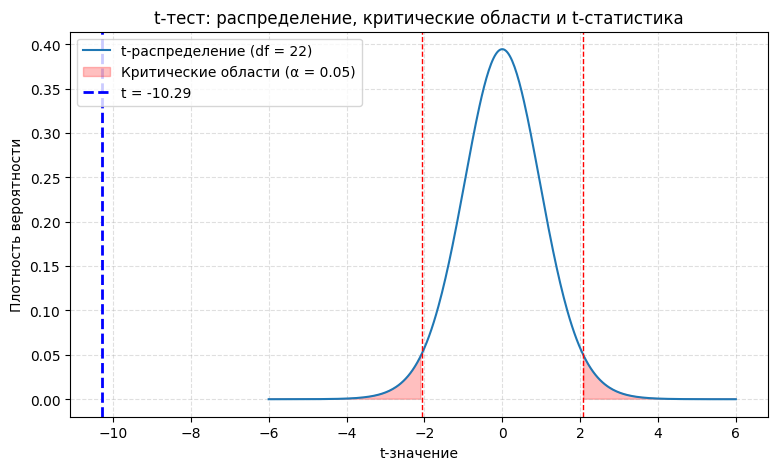

In [23]:
# Визуализация
# Параметры теста
n1, n2 = len(line_A), len(line_B)
df = n1 + n2 - 2  # степени свободы
alpha = 0.05

# Критическое значение для двустороннего теста
t_crit = stats.t.ppf(1 - alpha/2, df)

# Создание диапазона значений для распределения
x = np.linspace(-6, 6, 400)
y = stats.t.pdf(x, df)

# График распределения t
plt.figure(figsize=(9, 5))
plt.plot(x, y, label="t-распределение (df = %d)" % df)
plt.fill_between(x, y, where=(x < -t_crit) | (x > t_crit), color="red", alpha=0.25, label="Критические области (α = 0.05)")

# Отмечаем вычисленное значение t
plt.axvline(t_statistic, color="blue", linestyle="--", linewidth=2, label=f"t = {t_statistic:.2f}")
plt.axvline(-t_crit, color="red", linestyle="--", linewidth=1)
plt.axvline(t_crit, color="red", linestyle="--", linewidth=1)

# Подписи
plt.title("t-тест: распределение, критические области и t-статистика")
plt.xlabel("t-значение")
plt.ylabel("Плотность вероятности")
plt.legend()

plt.grid(alpha=0.4, linestyle="--")
plt.show()

##### <b><font color='saddlebrown'>1.3. Двухвыборочный t-тест с НЕ равной дисперсией</font></b>
stats.ttest_ind(a, b, equal_var = False)

Компания производит два типа аккумуляторов — модель X и модель Y.
Обе модели тестируются на время автономной работы (в минутах) при одинаковых условиях.

Однако инженеры знают, что:
- Модель X — более старая, стабильная технология, значит, меньше разброс значений.
- Модель Y — новая, но с нестабильным производственным процессом, следовательно, разброс (дисперсия) больше.

Модель X - 310, 305, 312, 303, 308, 307, 309, 311<br>
Модель Y - 320, 342, 335, 330, 350, 328, 345, 338, 355, 333

Проверить на уровне значимости α = 0.05,
различается ли среднее время работы между моделями X и Y.

In [24]:
# Запишите в список model_x и model_y значения из выборок
model_x = [310, 305, 312, 303, 308, 307, 309, 311]
model_y = [320, 342, 335, 330, 350, 328, 345, 338, 355, 333]

In [25]:
# Шаг 2. Вычисление статистики и p-value
# В переменные t_statistic, p_value запишите результат работы функции ttest_ind
# Функция ttest_ind принимает следующие параметры:
# a - первая выборка
# b - вторая выборка
# equal_var - True/False в зависимости от того, равные или нет дисперсии в группах
t_statistic, p_value = stats.ttest_ind(a = model_x, b = model_y, equal_var = False)

In [26]:
# Шаг 3. Интерпретация результатов
# Выведите t_statistic, p_value на экран и сделайте вывод по задаче
# Если p-value < 0.05, то отвергаем H₀, значит, средние различаются.
# Если p-value ≥ 0.05, то нет оснований утверждать, средние различаются.
print(f"T-статистика: {t_statistic}")
print(f"P-value: {p_value}")

T-статистика: -8.345460149146458
P-value: 4.946420658031593e-06


<b>Формулировка:</b>
На уровне значимости 0.05 среднее время работы модели X и модели Y различается. При этом среднее модели Y ниже.

##### <b><font color='saddlebrown'>1.4. Парный t-тест</font></b>
stats.ttest_rel(a, b)

Компания внедрила новый тренинг по повышению продуктивности для своих сотрудников. Для оценки его эффективности решили измерить количество обработанных заявок каждым сотрудником до и после тренинга.

Данные:
- Сотрудник 1: до — 45, после — 52
- Сотрудник 2: до — 38, после — 41
- Сотрудник 3: до — 50, после — 55
- Сотрудник 4: до — 42, после — 44
- Сотрудник 5: до — 47, после — 53

Вопрос:
Проверить на уровне значимости α = 0.05, увеличилась ли средняя производительность сотрудников после тренинга.

In [86]:
# в список before запишите количество отработанных заявок ДО тренинга
# в список after запишите количество отработанных заявок ПОСЛЕ тренинга
before = [45, 38, 50, 42, 47]
after = [52, 41, 55, 44, 53]

In [87]:
# Шаг 2. Вычисление статистики и p-value
# В переменные t_statistic, p_value запишите результат работы функции ttest_rel
# Функция ttest_rel принимает следующие параметры:
# a - первая выборка
# b - вторая выборка
t_statistic, p_value = stats.ttest_rel(a = after, b = before)

In [88]:
# Шаг 3. Интерпретация результатов
# Выведите t_statistic, p_value на экран и сделайте вывод по задаче
# Если p-value < 0.05, то отвергаем H₀, значит, На уровне значимости 0.05 средняя производительность после тренинга статистически значимо выше.
# Если p-value ≥ 0.05, Нет статистических доказательств того, что тренинг повысил среднюю производительность..
print(f"T-статистика: {t_statistic}")
print(f"P-value: {p_value}")

T-статистика: 4.960307567358167
P-value: 0.007704422069286503


### <b><font color='saddlebrown'>2. Z-тесты</font></b>

##### <b><font color='saddlebrown'>2.1. Одновыборочный z-тест</font></b>

Фабрика производит печенье по стандарту: каждая пачка должна весить 500 г.

Менеджер по качеству хочет проверить, соответствует ли средний вес пачки стандарту. Для этого он случайным образом взял 50 пачек и измерил их вес.

Средний вес выбранных пачек: 497 г
Известное стандартное отклонение веса пачек на фабрике: σ = 5 г

Вопрос:
На уровне значимости α = 0.05 проверить, отличается ли средний вес пачки от заявленного стандарта (500 г).

In [89]:
# В переменные sample_mean, population_mean, sigma, n запишите соответственно:
# средний вес в выборке, стандарт, стандартное отклонение и размер выборки
sample_mean = 497
population_mean = 500
sigma = 5
n = 50

In [90]:
# Вычислите Z-статистику в переменную z_stat
z_stat = (sample_mean - population_mean) / (sigma / n ** 0.5)
z_stat

-4.242640687119286

In [91]:
# Рассчитайте p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

In [92]:
# Шаг 3. Интерпретация результатов
# Выведите z_stat, p_value на экран и сделайте вывод по задаче
# Если p-value < 0.05, то отвергаем H₀, значит, На уровне значимости 0.05 средний вес пачки статистически значимо отличается от 500 г.
# Если p-value ≥ 0.05, Нет статистических доказательств, что средний вес пачки отличается от 500 г.
print(f"Z-статистика: {z_stat}")
print(f"P-value: {p_value}")

Z-статистика: -4.242640687119286
P-value: 2.2090496998528053e-05


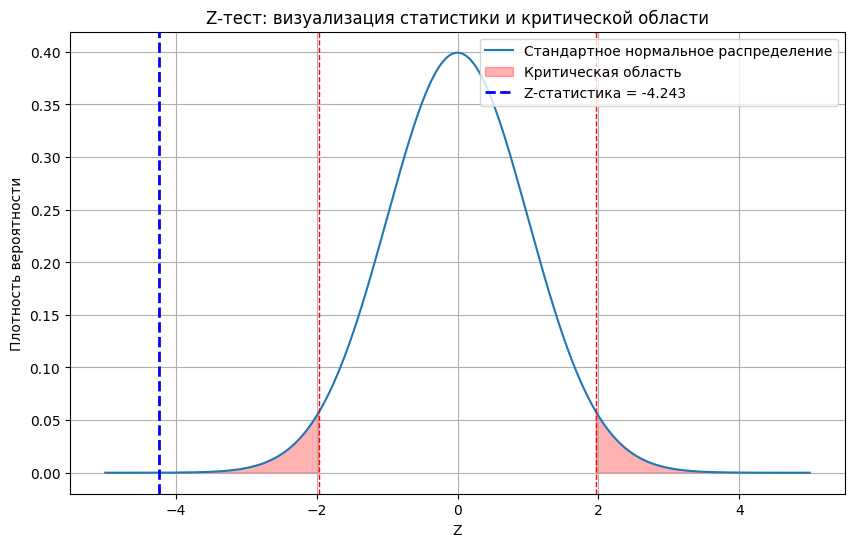

In [93]:
# Визуализация
x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x, 0, 1)

# Критические значения для двустороннего теста
z_crit = stats.norm.ppf(1 - alpha/2)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Стандартное нормальное распределение')
plt.fill_between(x, y, 0, where=(x <= -z_crit) | (x >= z_crit), color='red', alpha=0.3, label='Критическая область')
plt.axvline(z_stat, color='blue', linestyle='--', linewidth=2, label=f'Z-статистика = {z_stat:.3f}')
plt.axvline(-z_crit, color="red", linestyle="--", linewidth=1)
plt.axvline(z_crit, color="red", linestyle="--", linewidth=1)

plt.title('Z-тест: визуализация статистики и критической области')
plt.xlabel('Z')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.show()

##### <b><font color='saddlebrown'>2.2. Двухвыборочный z-тест</font></b>

Предположим, что фабрика в городах A и B производит мячи диаметром 5 см. Известно, что стандартное отклонение диаметра составляет 0,1. Специалист по качеству отбирает по 50 мячей с каждой фабрики, чтобы проверить, существенно ли отличаются диаметры мячей на двух фабриках.

In [116]:
# Моделирование наборов данных
factory_A = np.random.normal(loc = 5, scale = 0.1, size = 50)
factory_B = np.random.normal(loc = 5, scale = 0.1, size = 50)

In [117]:
# Шаг 2. Выполнение двухвыборочного Z-теста
from statsmodels.stats.weightstats import ztest
z_stat, p_value = ztest(factory_A, factory_B)

In [118]:
# Шаг 3. Вывод и интерпретация результатов
# Если p-value < 0.05, то отвергаем H₀, значит, Средние диаметры мячей на фабриках A и B статистически значимо различаются.
# Если p-value ≥ 0.05, Нет статистических доказательств различия средних диаметров мячей на фабриках A и B.
print(f"Z-статистика: {z_stat}")
print(f"P-value: {p_value}")

Z-статистика: -1.4106423531217296
P-value: 0.15835009668066113


##### <b><font color='saddlebrown'>2.3. Парный z-тест</font></b>

Фитнес-клуб хочет проверить, влияет ли новая программа тренировок на уровень силы своих клиентов.
30 участников проходят тест на максимальное количество отжиманий до начала программы.
Затем они проходят 8 недель тренировок, после чего проводится тот же тест.
Известно, что стандартное отклонение разницы количества отжиманий для всей популяции σ = 5.
Вопрос: Статистически значимо ли увеличилось количество отжиманий после тренировки?

In [119]:
# Генерация данных
before = np.array([20, 25, 18, 22, 24, 19, 21, 23, 20, 22,
          19, 21, 20, 23, 24, 22, 21, 20, 19, 22,
          23, 24, 21, 22, 20, 19, 21, 23, 22, 20])
after  = np.array([22, 27, 20, 25, 26, 21, 23, 25, 22, 24,
          21, 23, 22, 25, 27, 24, 23, 22, 21, 24,
          25, 26, 23, 24, 22, 21, 23, 25, 24, 22])

In [120]:
# Шаг 2. Выполнение парного Z-теста
z_stat, p_value = ztest(after - before)

In [121]:
# Шаг 3. Вывод и интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Количество отжиманий после 8 недель тренировок статистически значимо.")
else:
    print("Нет статистических доказательств, что 8 недель тренировок увеличили количество отжиманий.")
print(z_stat)
print(p_value)

Количество отжиманий после 8 недель тренировок статистически значимо.
44.61662086199332
0.0


### <b><font color='saddlebrown'>3. Решение задач</font></b>

##### <b><font color='saddlebrown'>Задача 1</font></b>

<b>Задача:</b>

Компания продаёт два вида упаковки кофе: Классическая и Премиум.<br>
Менеджер по продажам хочет понять, отличается ли средний объём продаж за неделю между этими двумя упаковками.

- Случайным образом отобраны 10 магазинов, которые продают Классическую упаковку, и 10 магазинов, которые продают Премиум.
- За неделю собираются данные о количестве проданных упаковок в каждом магазине.
- Компания предполагает, что дисперсия продаж одинакова для обеих упаковок.

<b>Вопрос:</b> Есть ли статистически значимое различие в среднем объёме продаж между Классической и Премиум упаковками?

In [122]:
# Генерация данных
classic_sales = np.array([120, 135, 150, 128, 142, 138, 131, 145, 137, 140])
premium_sales = np.array([130, 148, 155, 140, 150, 147, 145, 152, 149, 151])

In [137]:
# Шаг 2. Вычислите статистику и p-value в переменные stat_1 и p_value
t_statistic, p_value = stats.ttest_ind(a = classic_sales, b = premium_sales, equal_var = True)


In [138]:
# Шаг 3. Выведите результаты и интерпретируйте их
print(f"T-статистика: {t_statistic}")
print(f"P-value: {p_value}")

T-статистика: -2.8422214222833513
P-value: 0.010811121767836362


##### <b><font color='saddlebrown'>Задача 2</font></b>

<b>Задача:</b>

Городская администрация хочет проверить, соответствует ли средний возраст жителей нового жилого комплекса среднему возрасту по городу.

- Известно, что средний возраст жителей города составляет 35 лет, а стандартное отклонение возраста в городе σ = 10 лет.
- Администрация случайным образом опросила 60 жителей нового жилого комплекса и получила средний возраст 37 лет.

<b>Вопрос:</b> Статистически значимо ли средний возраст жителей нового комплекса отличается от среднего возраста по городу при статистической значимости 0.01?

In [139]:
# В переменные sample_mean, population_mean, sigma, n запишите соответственно:
# средний возраст в выборке, средний возраст по городу, стандартное отклонение и размер выборки
sample_mean = 37
population_mean = 35
sigma = 10
n = 60
alpha = 0.01


In [140]:
# Шаг 2. Вычислите статистику в переменную stat_2 и p_value
z_stat = (sample_mean - population_mean) / (sigma / n ** 0.5)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))


In [141]:
# Шаг 3. Выведите результаты и интерпретируйте их
print(f"Z-статистика: {z_stat}")
print(f"P-value: {p_value}")

Z-статистика: 1.5491933384829668
P-value: 0.12133525035848214


##### <b><font color='saddlebrown'>Задача 3</font></b>

<b>Задача:</b>

Городская администрация хочет проверить эффективность новой программы по раздельному сбору мусора.

- В 15 жилых кварталах замеряли среднее количество мусора (в кг) на одного жителя за неделю до внедрения программы.
- После 3 месяцев работы программы измерения повторили в тех же кварталах.

<b>Вопрос:</b> Статистически значимо ли уменьшилось количество мусора на одного жителя после внедрения программы?

In [180]:
# Генерация данных
before = [12.5, 13.2, 11.8, 14.0, 12.9, 13.5, 12.7, 13.1, 12.3, 13.0, 12.8, 13.4, 12.6, 13.3, 12.9]
after  = [11.0, 12.0, 10.5, 12.8, 11.5, 12.3, 11.7, 12.0, 11.2, 11.8, 11.5, 12.1, 11.3, 12.0, 11.7]

In [181]:
# Шаг 2. Вычислите статистику в переменную stat_3 и p_value
stat_3, p_value = stats.ttest_rel(a = before, b = after)

In [182]:
# Шаг 3. Выведите результаты и интерпретируйте их
print(f"T-статистика: {stat_3}")
print(f"P-value: {p_value}")

T-статистика: 38.66379299666405
P-value: 1.2450679573991316e-15


### <b><font color='saddlebrown'>4. Хи-квадрат тесты</font></b>

##### <b><font color='saddlebrown'>4.1. Тест независимости</font></b>

In [183]:
# Импорт библиотек
from scipy.stats import chi2_contingency
import seaborn as sns
import pandas as pd

In [189]:
# Загрузка данных
titanic = sns.load_dataset('titanic')
display(titanic.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [185]:
# Создание таблицы случайностей
contingency_table = pd.crosstab(titanic['class'], titanic['survived'])
print(contingency_table)

survived    0    1
class             
First      80  136
Second     97   87
Third     372  119


In [186]:
# Выполенение теста хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)

In [187]:
# Вывод и интерпретация результатов
print(f"Статистика хи-квадрат: {chi2}")
print(f"P-value: {p}")
print(f"Степени свободы: {dof}")
print("Ожидаемые частоты:")
print(expected)

Статистика хи-квадрат: 102.88898875696056
P-value: 4.549251711298793e-23
Степени свободы: 2
Ожидаемые частоты:
[[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


##### <b><font color='saddlebrown'>4.2. Тест на добросовестность соответствия</font></b>

Задача. В генеральной совокупности доля мужчин и женщин считается одинаковой: 
p_м = 0.5, p_ж = 0.5. <br>
В случайной выборке n=200 получили:

- Мужчин — 90
- Женщин — 110

Проверим гипотезу, что выборка соответствует ожидаемому равномерному распределию (т.е. 50%/50%) на уровне значимости α=0.05.

In [188]:
from scipy.stats import chisquare

observed = [90, 110]
expected = [100, 100]  
chi2, p = chisquare(f_obs=observed, f_exp=expected)
print(chi2, p)  

2.0 0.15729920705028105
